# Eigenmode analysis: normalized with-self vs no-self

Both source→receiver matrices are normalized independently to spectral radius 0.95 before the corrected left-action Schur analysis. This isolates structural changes caused by removing the diagonal from simple global-scale changes.

## Notebook role in the analysis sequence

**Role:** Companion to `01_schur_eigenmodes.ipynb`.

**Inputs:**
- `matrices/mij_matrix.csv`

**Outputs:**
- No required downstream files; this is a sensitivity check for the foundational modal structure.

**What this notebook adds:**
- Repeats the corrected Schur/eigenmode analysis after removing self-connections.
- Normalizes with-self and no-self variants independently to spectral radius `0.95`.
- Quantifies whether the dominant mode and upstream Schur structure are preserved without diagonal entries.


In [1]:
from pathlib import Path
from IPython.display import display
from schur_analysis_utils_script import (
    compare_left_action_self_conditions,
    load_connectivity_matrix,
    plot_eigenvalue_spectrum,
)

MATRIX_PATH = Path('matrices/mij_matrix.csv')
TARGET_SPECTRAL_RADIUS = 0.95

## Run the matched comparison

In [2]:
matrix = load_connectivity_matrix(MATRIX_PATH)
comparison = compare_left_action_self_conditions(
    matrix,
    normalization='spectral_radius',
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
)
display(comparison['summary'])

Loaded connectivity matrix of shape: (85, 85)


ValueError: underlying array is read-only

## Eigenvalue spectra


with_self


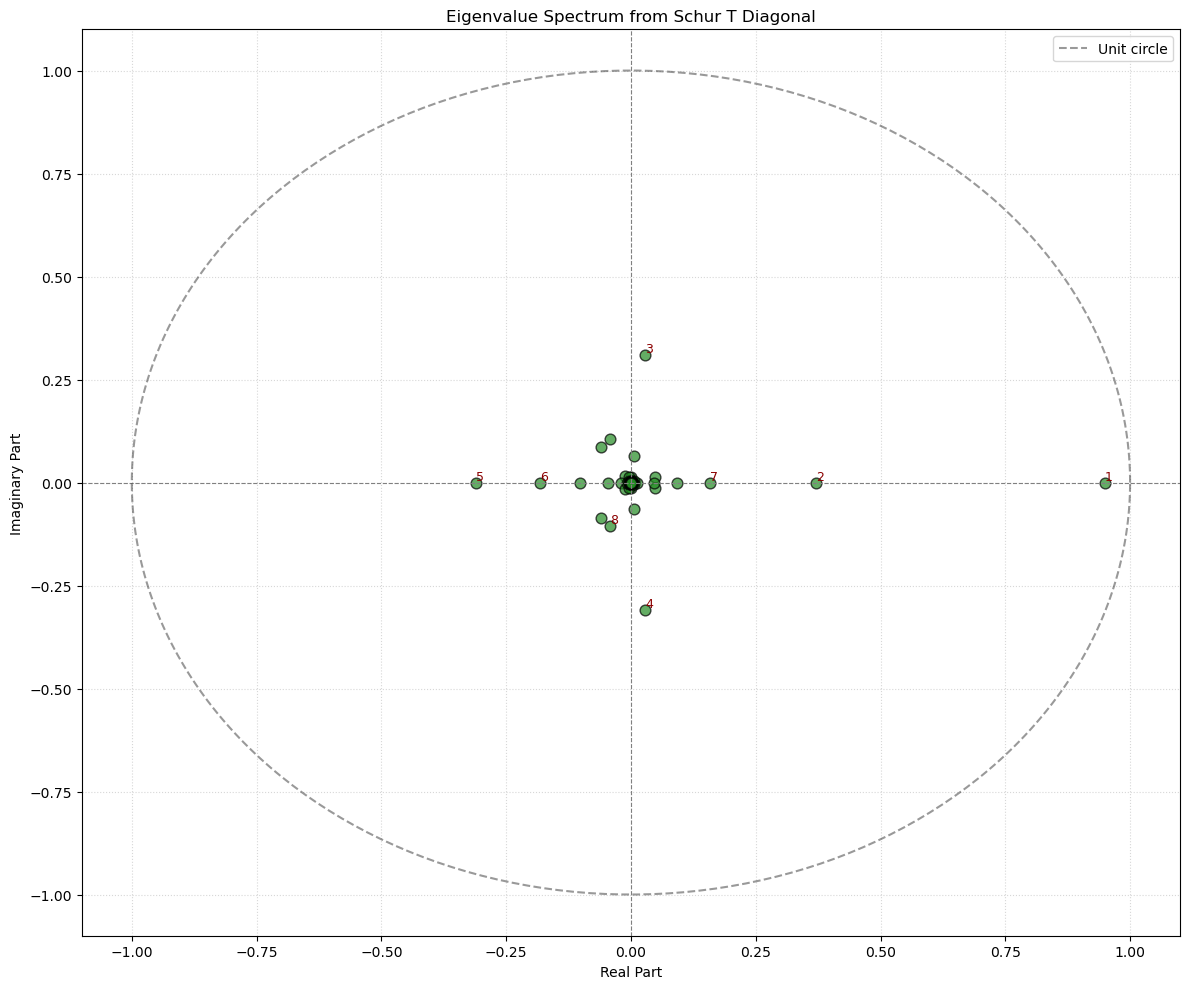


no_self


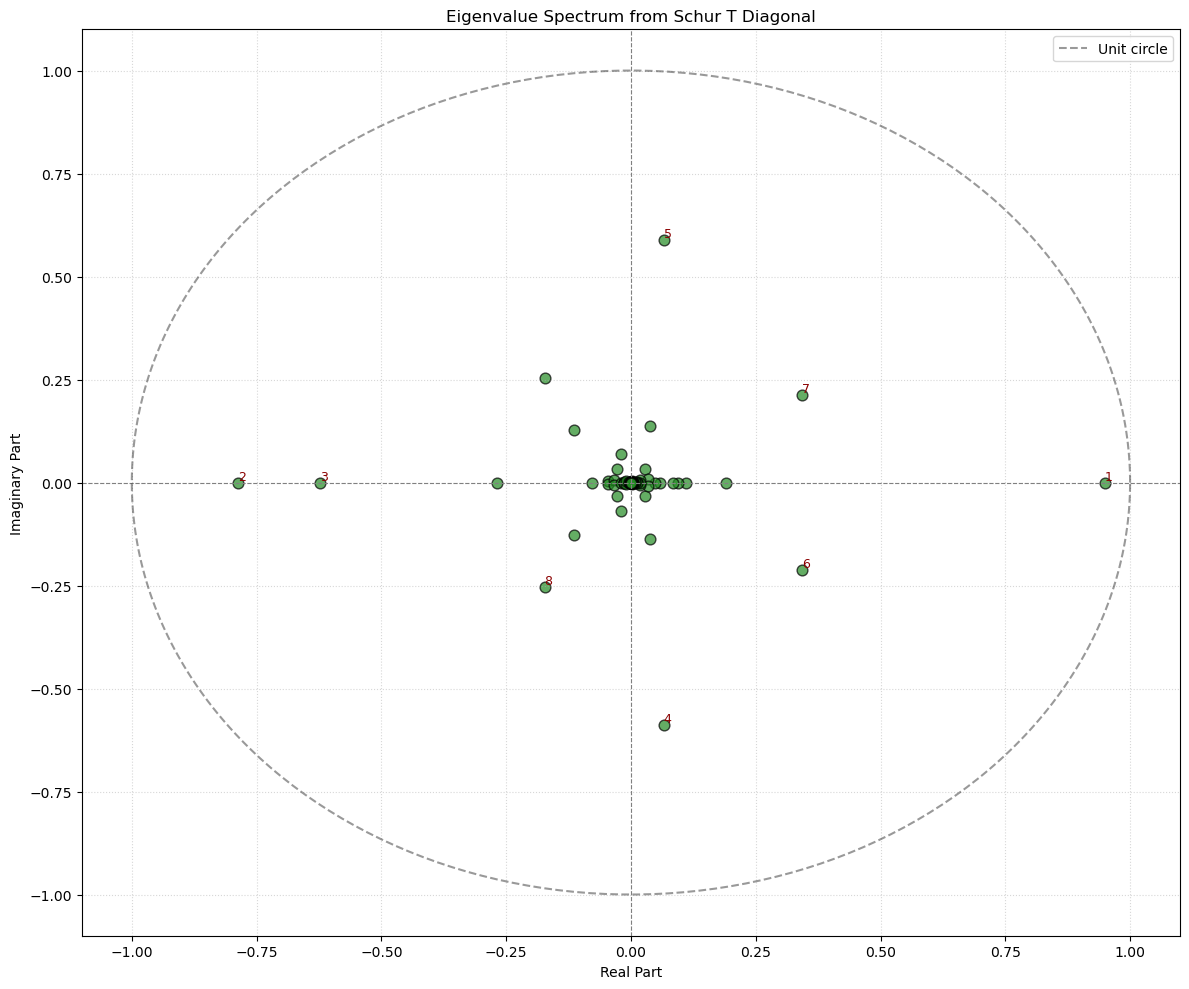

In [ ]:
for variant, result in comparison['analyses'].items():
    print(f'\n{variant}')
    plot_eigenvalue_spectrum(result['eigenvalues'], annotate_top=8)

## Upstream-mode summaries

In [ ]:
display(comparison['with_self_modes'].head(20))
display(comparison['no_self_modes'].head(20))
print(f"Dominant eigenvector overlap: {comparison['dominant_vector_overlap']:.6f}")

,Cascade step,Schur index,Type,lambda,|lambda|,Top left-vector/action cell,Top Schur-state cell,Incoming count,Outgoing count
0,1,85,Real,-0.0000,1.491211e-06,EC LI II Pyramidal Fan (E),EC LI II Pyramidal Fan (E),0,84
1,2,84,Real,0.0000,8.492493e-06,EC LI II Pyramidal Fan (E),MEC LV Pyramidal (E),1,83
2,3,83,Real,0.0000,1.477658e-07,EC LI II Pyramidal Fan (E),CA3 Trilaminar (I),2,81
3,4,82,Real,0.0000,3.274481e-06,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),2,77
4,5,81,Real,-0.0000 + 0.0000i,6.324881e-06,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),3,79
5,6,80,Real,-0.0000 - 0.0000i,6.324881e-06,EC LI II Pyramidal Fan (E),CA1 Recurrent O LM (I),4,79
6,7,79,Real,0.0000,7.246394e-06,EC LI II Pyramidal Fan (E),CA1 O LMR (I),5,77
7,8,78,Complex Pair,-0.0000 + 0.0000i,1.681992e-05,EC LI II Pyramidal Fan (E),CA1 Radiatum Giant (I),6,77
8,9,76,Real,0.0000,1.707280e-05,EC LI II Pyramidal Fan (E),CA1 Radiatum Giant (I),7,74
9,10,75,Complex Pair,0.0000 - 0.0000i,2.277927e-05,EC LI II Pyramidal Fan (E),CA3 Horizontal Axo Axonic (I),10,73


,Cascade step,Schur index,Type,lambda,|lambda|,Top left-vector/action cell,Top Schur-state cell,Incoming count,Outgoing count
0,1,85,Real,0.0000 - 0.0000i,0.000048,EC LI II Pyramidal Fan (E),EC LI II Pyramidal Fan (E),0,83
1,2,84,Real,0.0000 + 0.0000i,0.000048,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),0,83
2,3,83,Real,0.0001,0.000077,EC LI II Pyramidal Fan (E),CA2 SP SR (I),2,81
3,4,82,Real,-0.0000,0.000002,EC LI II Pyramidal Fan (E),CA3 Trilaminar (I),3,81
4,5,81,Real,0.0001 + 0.0000i,0.000119,EC LI II Pyramidal Fan (E),CA1 Radiatum Giant (I),4,80
5,6,80,Real,0.0001 - 0.0000i,0.000119,EC LI II Pyramidal Fan (E),CA3 Pyramidal (E),5,79
6,7,79,Complex Pair,-0.0000 - 0.0000i,0.000033,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),6,78
7,8,77,Real,-0.0001,0.000090,CA1 Radiatum Giant (I),MEC LV Pyramidal (E),8,76
8,9,76,Complex Pair,0.0001 - 0.0001i,0.000117,EC LI II Pyramidal Fan (E),DG HIPP (I),9,75
9,10,74,Real,0.0002,0.000226,EC LI II Pyramidal Fan (E),MEC LII III Pyramidal Multiform (E),10,72


Dominant eigenvector overlap: 0.901180
